**3개 모델 사용 결과**
- LightGBM과 Catboost 중 하나 사용
- 정확도가 중요하다면 Cat, 성공 매물을 하나라도 더 잡아내려면 LightGBM
- 매물의 추천 개수를 제한하여 정확도를 높이는 것이 좋을 듯
- 클래스 3개로 다중분류 시도했으나 정확도 오히려 더 낮게 나옴 
- **CatBoost** 사용, **parameter** 조정 필요

# 완료 코드

In [14]:
"""랜덤포레스트 활용:
class_weight, SMOTE 오버샘플링, 그리드서치, threshold 완화 등 모두 사용해 보았으나,
성공한 카페에 대한 예측 정확도가 너무 떨어지는 관계로 우선 skip함
"""
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
# 랜덤 포레스트 학습
# 데이터 로드 및 전처리
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']] = cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']].fillna(0)

# 층수 처리
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1  # 오류가 나는 경우는 1층으로 처리
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

train_cols = ['층정보','지하철역_거리(m)','버스정류장_거리(m)','반경500m내_카페수', '평일_대비_주말_유동인구_비율','도로2m이내접촉길이_m','집객시설_수', '지하철_역_수','버스_정거장_수','평균_평일_유동인구_수', '평균_주말_유동인구_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수','est_시간대_11_14_유동인구_수']
X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Best Parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

# 오버샘플링
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
# 하이퍼파라미터 그리드 설정
rf_model = RandomForestClassifier(
    class_weight = None, max_depth= 10, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 100
)

# 학습
rf_model.fit(X_train, y_train)


# 확률값 예측 (1 클래스에 대한 확률만 추출)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 원하는 threshold 설정
threshold = 0.3  # 기본값 0.5보다 낮춰서 더 많은 1을 예측하도록 함
y_pred_thresholded = (y_probs >= threshold).astype(int)

# 성능 평가
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_thresholded))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_thresholded))

# 성공할 카페를 판단하는 데 좋지 않은 모습, skip
# threshold 사용하면 정확도 너무 많이 떨어진다. (56%)

Confusion Matrix:
[[766 851]
 [233 430]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.47      0.59      1617
         1.0       0.34      0.65      0.44       663

    accuracy                           0.52      2280
   macro avg       0.55      0.56      0.51      2280
weighted avg       0.64      0.52      0.54      2280



threshold = 0.4
Confusion Matrix:
[[793 824]
 [278 385]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.49      0.59      1617
         1.0       0.32      0.58      0.41       663

    accuracy                           0.52      2280
   macro avg       0.53      0.54      0.50      2280
weighted avg       0.62      0.52      0.54      2280

ROC AUC Score: 0.5465


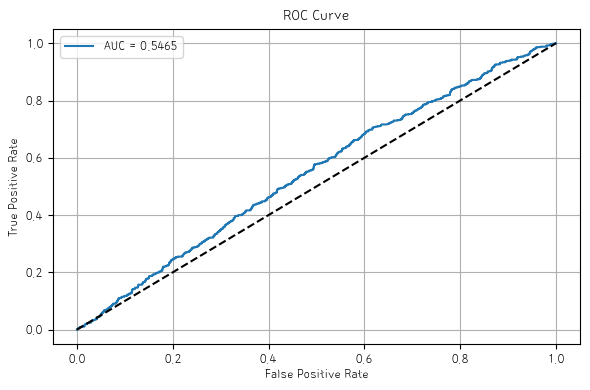

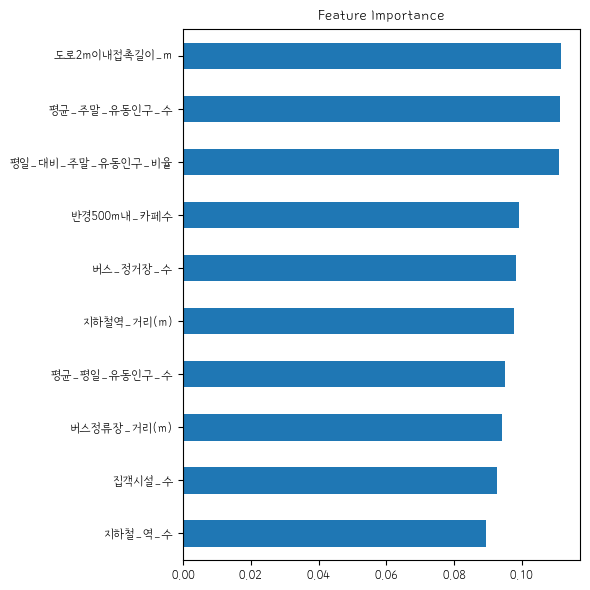

In [17]:
"""XGB 사용 결과
랜덤포레스트보다 조금 나은 성능 (데이터 라벨 불균형 어느 정도 잡아줌)
성공할 만한 매물을 추천하는 데는 나쁘지 않은 정도, 다른 것들을 사용해 보고 다음에 피처 조정
"""
# XGBoost 사용
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']] = cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']].fillna(0)

# 층수 처리
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1  # 오류가 나는 경우는 1층으로 처리
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

train_cols = ['지하철역_거리(m)','버스정류장_거리(m)','반경500m내_카페수', '평일_대비_주말_유동인구_비율','도로2m이내접촉길이_m','집객시설_수', '지하철_역_수','버스_정거장_수','평균_평일_유동인구_수', '평균_주말_유동인구_수']
X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 클래스 비율: 7:3 => scale_pos_weight = 7 / 3 ≈ 2.33
xgb_model = XGBClassifier(scale_pos_weight=2.33, max_depth=6, n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# 평가 ###########

# 1. 확률예측
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2. threshold 조정 (기본: 0.35)
threshold = 0.4
y_pred_custom = (y_proba >= threshold).astype(int)
print(f'threshold = {threshold}')
# 3. confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

# 4. classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

# 5. ROC AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

# 6. ROC Curve 시각화
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

feat_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=True).plot(kind='barh', figsize=(6, 6), title='Feature Importance')
plt.tight_layout()
plt.show()


threshold = 0.4
Confusion Matrix:
[[ 446 1171]
 [ 128  535]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.28      0.41      1617
         1.0       0.31      0.81      0.45       663

    accuracy                           0.43      2280
   macro avg       0.55      0.54      0.43      2280
weighted avg       0.64      0.43      0.42      2280

ROC AUC Score: 0.5720


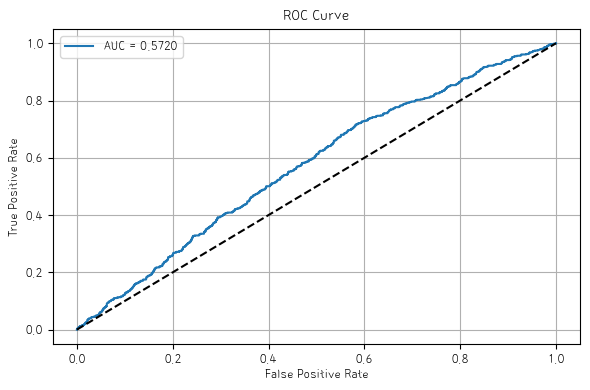

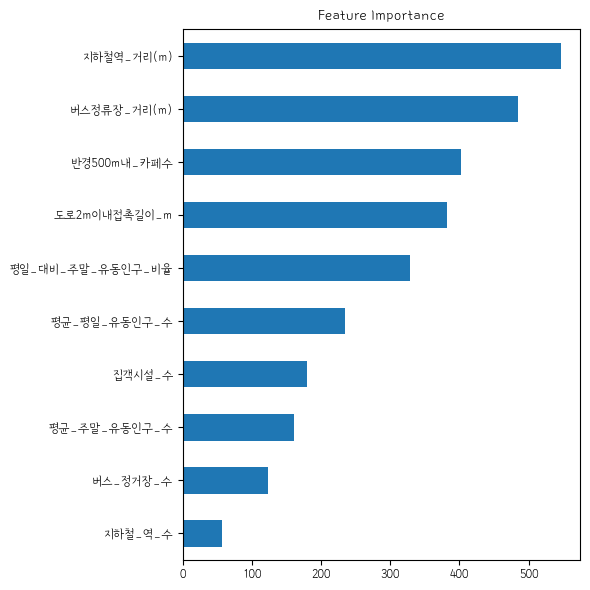

In [18]:
"""LightGBM
파라미터 조정 시 같은 threshold에서 정확도 0.66의 xgboost보다 조금 더 나은 성능을 보임
"""
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# train set 세팅
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']] = cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']].fillna(0)

# 층수 처리
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1  # 오류가 나는 경우는 1층으로 처리
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

train_cols = ['지하철역_거리(m)','버스정류장_거리(m)','반경500m내_카페수', '평일_대비_주말_유동인구_비율','도로2m이내접촉길이_m','집객시설_수', '지하철_역_수','버스_정거장_수','평균_평일_유동인구_수', '평균_주말_유동인구_수']
X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 학습 ##########

lgb_params = {
    'objective': 'binary',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 10,
    'min_gain_to_split': 0.0,
    'max_depth': 6,
    'verbose': -1
}

lgbm_model = LGBMClassifier(**lgb_params, n_estimators=100, class_weight='balanced')
lgbm_model.fit(X_train, y_train)

# 평가 ###########

# 1. 확률예측
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

# 2. threshold 조정 (기본: 0.35)
threshold = 0.4
y_pred_custom = (y_proba >= threshold).astype(int)
print(f'threshold = {threshold}')
# 3. confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

# 4. classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

# 5. ROC AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

# 6. ROC Curve 시각화
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

feat_importance = pd.Series(lgbm_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=True).plot(kind='barh', figsize=(6, 6), title='Feature Importance')
plt.tight_layout()
plt.show()



Best Trial: {'iterations': 110, 'depth': 7, 'learning_rate': 0.1184684763691007, 'l2_leaf_reg': 6.385887497530427}

✅ Threshold = 0.5
📌 Confusion Matrix:
[[926 691]
 [282 381]]

📌 Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.57      0.66      1617
         1.0       0.36      0.57      0.44       663

    accuracy                           0.57      2280
   macro avg       0.56      0.57      0.55      2280
weighted avg       0.65      0.57      0.59      2280


✅ ROC AUC Score: 0.6080


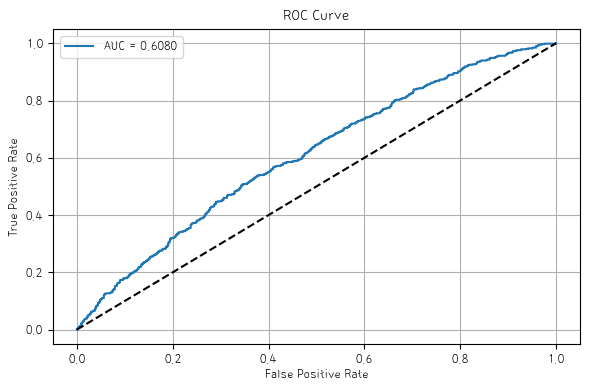

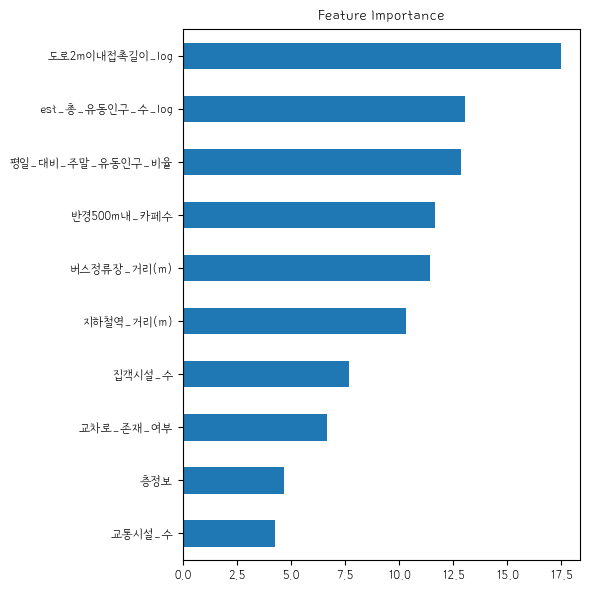

In [16]:
# ✅ 전체 통합 코드 (CatBoost + Optuna 튜닝 포함)
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, make_scorer
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from collections import Counter
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) ## 로그 제거

# ------------------ 한글 폰트 설정 ------------------
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ------------------ 데이터 불러오기 ------------------
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)

fill_cols = ['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수',
             '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수',
             '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수']
cafe_cleaned[fill_cols] = cafe_cleaned[fill_cols].fillna(0)
cafe_cleaned['교통시설_수'] = cafe_cleaned['버스_정거장_수'] + cafe_cleaned['지하철_역_수']

# ------------------ 층수 처리 ------------------
def convert_floor(floor):
    try:
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1

cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

# ------------------ 로그 변환 ------------------
cafe_cleaned['도로2m이내접촉길이_log'] = np.log1p(cafe_cleaned['도로2m이내접촉길이_m'])
cafe_cleaned['est_총_유동인구_수_log'] =  np.log1p(cafe_cleaned['est_총_유동인구_수'])

# ------------------ 모델 학습용 컬럼 ------------------
train_cols = ['집객시설_수','지하철역_거리(m)','교차로_존재_여부', 'est_총_유동인구_수_log', '버스정류장_거리(m)', '평일_대비_주말_유동인구_비율', '반경500m내_카페수', '교통시설_수', '도로2m이내접촉길이_log', '층정보']

X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']

# ------------------ Train/Test 분리 ------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------ 클래스 비율로 가중치 설정 ------------------
counter = Counter(y_train)
scale = counter[0] / counter[1]  # 예: 9.5 정도

# ------------------ Optuna 튜닝 ------------------
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "scale_pos_weight": scale,
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostClassifier(**params)
    
    # class 1 precision을 최적화하는 scoring 함수
    precision_scorer = make_scorer(precision_score, pos_label=1, average='binary')
    
    score = cross_val_score(model, X_train, y_train, cv=3,
                            scoring=precision_scorer).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Trial:", study.best_trial.params)

# ------------------ 최적 모델로 재학습 ------------------
best_params = study.best_trial.params
best_params["scale_pos_weight"] = scale
best_params["random_state"] = 42
best_params["verbose"] = 0

best_model = CatBoostClassifier(**best_params)
best_model.fit(X_train, y_train)

# ------------------ 모델 평가 ------------------
y_proba = best_model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred_custom = (y_proba >= threshold).astype(int)

print(f"\n✅ Threshold = {threshold}")
print("📌 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred_custom))

auc_score = roc_auc_score(y_test, y_proba)
print(f"\n✅ ROC AUC Score: {auc_score:.4f}")

# ------------------ ROC Curve ------------------
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\시각화\optuna_precision_ROC.png')
plt.show()

# ------------------ Feature Importance ------------------
feat_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=True).plot(kind='barh', figsize=(6, 6), title='Feature Importance')
plt.tight_layout()
plt.savefig(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\시각화\optuna_precision_중요도.png')
plt.show()


In [ ]:
# precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# plt.figure(figsize=(8,5))
# plt.plot(thresholds, precisions[:-1], label='Precision')
# plt.plot(thresholds, recalls[:-1], label='Recall')
# plt.xlabel('Threshold')
# plt.ylabel('Score')
# plt.title('Precision vs Recall vs Threshold')
# plt.grid()
# plt.legend()
# plt.show()

# 사용 코드

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
sale = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\매물_피처병합_수정.csv', low_memory=False)

intersection = list(set(cafe) & set(sale))
# print( intersection )
inter_filtered = ['집객시설_수', '상권_코드', '지하철역_거리(m)', '버스_정거장_수', '교차로_존재_여부', '약국_수', 
 '초등학교_수', '백화점_수', 'est_총_유동인구_수', '지하철_역_수', '관공서_수', '일반_병원_수', 
 '숙박_시설_수', '종합병원_수', '중학교_수', '버스정류장_거리(m)', '슈퍼마켓_수', 
 '평일_대비_주말_유동인구_비율', '대학교_수', '은행_수', '고등학교_수', '반경500m내_카페수', 
 '접한길이_m', '도로2m이내접촉길이_m', '유치원_수', '극장_수']

print(sale['tagList'].head(10))

0           NaN
1           NaN
2        3.8430
3           NaN
4           NaN
          ...  
18166    4.7350
18167    3.4400
18168    2.5415
18169    3.6420
18170    3.2000
Name: 총점, Length: 18171, dtype: float64
0        ['10년이내', '지하층', '주차가능', '천장에어컨']
1          ['15년이내', '융자금적은', '테라스', '1층']
2           ['25년이상', '역세권', '중층', '주차가능']
3          ['15년이내', '지하층', '주차가능', '남동향']
4    ['25년이상', '지하층', '관리비10만원이하', '주차가능']
5         ['25년이상', '1층', '주차가능', '천장에어컨']
6           ['25년이상', '지하층', '총4층', '북서향']
7           ['25년이상', '1층', '주차가능', '총5층']
8           ['25년이내', '중층', '주차가능', '남서향']
9           ['25년이상', '역세권', '1층', '주차가능']
Name: tagList, dtype: object


threshold = 0.5
Confusion Matrix:
[[926 691]
 [282 381]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.57      0.66      1617
         1.0       0.36      0.57      0.44       663

    accuracy                           0.57      2280
   macro avg       0.56      0.57      0.55      2280
weighted avg       0.65      0.57      0.59      2280

ROC AUC Score: 0.6080


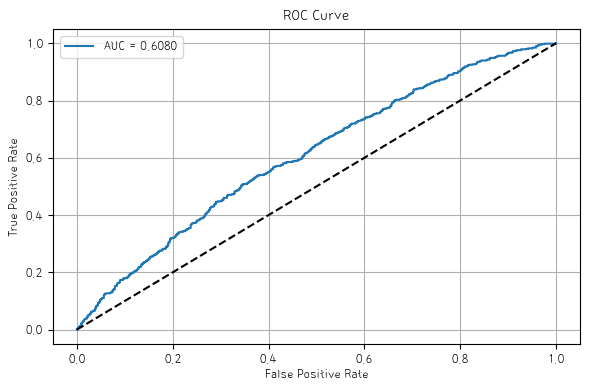

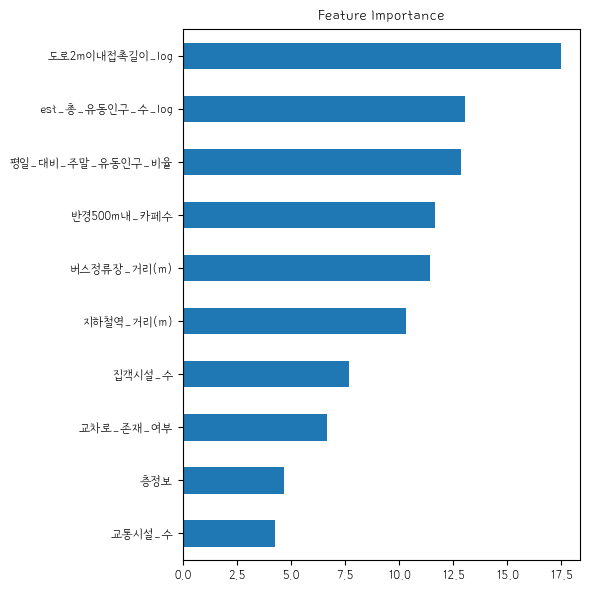

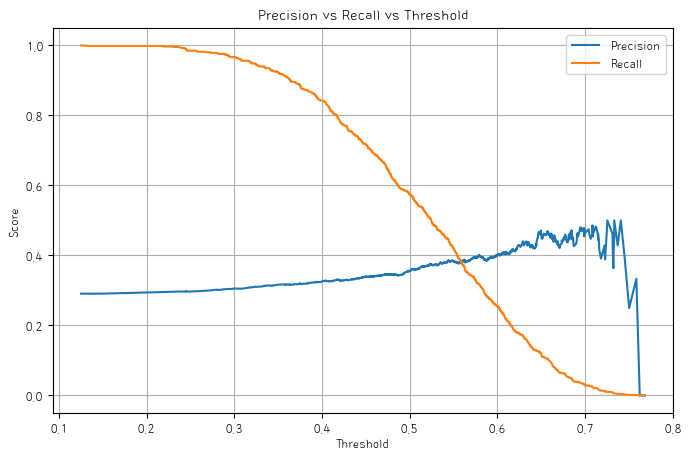

In [18]:
"""CatBoost 사용 및 조정 중"""
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from collections import Counter
from sklearn.metrics import precision_recall_curve

# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# train set 세팅
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수']] = cafe_cleaned[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수']].fillna(0)
cafe_cleaned['교통시설_수'] = cafe_cleaned['버스_정거장_수'] + cafe_cleaned['지하철_역_수']
# 층수 처리
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1  # 오류가 나는 경우는 1층으로 처리
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)


# 극단값 로그 변환
cafe_cleaned['도로2m이내접촉길이_log'] = np.log1p(cafe_cleaned['도로2m이내접촉길이_m'])
cafe_cleaned['est_총_유동인구_수_log'] =  np.log1p(cafe_cleaned['est_총_유동인구_수'])
cafe_cleaned['지하철역_거리(m)'] = np.log1p(cafe_cleaned['지하철역_거리(m)'])
cafe_cleaned['버스정류장_거리(m)'] = np.log1p(cafe_cleaned['버스정류장_거리(m)'])

train_cols = ['집객시설_수','지하철역_거리(m)','교차로_존재_여부', 'est_총_유동인구_수_log', '버스정류장_거리(m)', '평일_대비_주말_유동인구_비율', '반경500m내_카페수', '교통시설_수', '도로2m이내접촉길이_log', '층정보']

X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
counter = Counter(y_train)  
scale = counter[0] / counter[1]  # 예: 9.5 정도일 수 있음

# optuna 수치로 맞춤
# (최고의 Precision Score: 성공 매물을 예측했을 때 가능성 증가?)
# Best Trial: {'iterations': 110, 'depth': 7, 'learning_rate': 0.1184684763691007, 'l2_leaf_reg': 6.385887497530427}
cat_model = CatBoostClassifier(
    scale_pos_weight=scale,
    iterations=110, 
    depth=7, 
    learning_rate=0.1184684763691007,
    l2_leaf_reg=  6.385887497530427,
    random_state=42, 
    verbose=0)
cat_model.fit(X_train, y_train)
    
# 평가 ###########

# 1. 확률예측
y_proba = cat_model.predict_proba(X_test)[:, 1]

# 2. threshold 조정 (기본: 0.35)
threshold = 0.5
y_pred_custom = (y_proba >= threshold).astype(int)
print(f'threshold = {threshold}')

# 3. confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

# 4. classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

# 5. ROC AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

# 6. ROC Curve 시각화
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

feat_importance = pd.Series(cat_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=True).plot(kind='barh', figsize=(6, 6), title='Feature Importance')
plt.tight_layout()
plt.show()


precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()


In [19]:
# 데이터 가공 및 정리
import pandas as pd
import re
import numpy as np
import sys

sale = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\매물_피처병합_수정.csv', low_memory=False)

# print(sale.columns.tolist())
# 상권 내 매물이 아니면 drop
sale = sale.dropna(subset=['상권_코드','articleNo'])
print(f'추천 가능한 매물 수: {len(sale)}')

# 금액 전환
def parse_price_to_manwon(price_str): # 금액 숫자로 전환
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).strip().replace(",", "").replace(" ", "")
    
    if "억" in price_str:
        match = re.match(r"(\d+)억(\d+)?", price_str)
        if match:
            billion = int(match.group(1)) * 10000
            thousand = int(match.group(2)) if match.group(2) else 0
            return billion + thousand
        else:
            return int(price_str.replace("억", "")) * 10000
    elif price_str.isdigit():
        return int(price_str)
    else:
        return pd.to_numeric(price_str, errors='coerce')
sale['rentPrc'] = sale['rentPrc'].apply(parse_price_to_manwon)
sale['dealOrWarrantPrc'] = sale['dealOrWarrantPrc'].apply(parse_price_to_manwon)

# 층수 처리
def process_floor(floor_str):
    floor = floor_str.split('/')[0]
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        else:
            return int(floor)
    except:
        return 1  # 오류가 나는 경우는 1층으로 처리
sale['층정보'] = sale['floorInfo'].apply(process_floor)
sale['도로2m이내접촉길이_log'] = np.log1p(sale['도로2m이내접촉길이_m'])

# 결측치 처리
sale[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수','반경500m내_카페수', '접한길이_m', '도로2m이내접착길이_m','지하철역_거리(m)', '버스정류장_거리(m)']] = sale[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수','반경500m내_카페수', '접한길이_m', '도로2m이내접촉길이_m','지하철역_거리(m)', '버스정류장_거리(m)']].fillna(0)
# 컬럼명 오타 수정 (접착 → 접촉) # 완전 수정함
sale['도로2m이내접촉길이_log'] = np.log1p(sale['도로2m이내접촉길이_m'])
sale['est_총_유동인구_수_log'] = np.log1p(sale['est_총_유동인구_수'])
sale['교통시설_수'] = sale['버스_정거장_수'] + sale['지하철_역_수']
sale['est_총_유동인구_수'] = sale['est_총_유동인구_수'].fillna(sale['est_총_유동인구_수'].mean())

# 데이터 형식
sale['상권_코드'] = sale['상권_코드'].astype(int)
sale['교차로_존재_여부'] = sale['교차로_존재_여부'].astype(int)

train_cols = ['집객시설_수','지하철역_거리(m)','교차로_존재_여부', 'est_총_유동인구_수_log', '버스정류장_거리(m)', '평일_대비_주말_유동인구_비율', '반경500m내_카페수', '교통시설_수', '도로2m이내접촉길이_log', '층정보']

# 사용자 실습
def recommend_top_properties(
    df, model, selected_areas, trade_type,
    max_rent=None, max_deposit=None, max_deal_price=None, top_n=5
):
    # 1. 상권, 거래유형 필터링
    filtered = df[
        (df['상권_코드'].isin(selected_areas)) &
        (df['tradeTypeName'] == trade_type)
    ].copy()

    # 2. 금액 조건 필터링
    if trade_type == '월세':
        filtered = filtered[
            (filtered['rentPrc'] <= max_rent) &
            (filtered['dealOrWarrantPrc'] <= max_deposit)
        ]
    elif trade_type == '매매':
        filtered = filtered[
            (filtered['dealOrWarrantPrc'] <= max_deal_price)
        ]

    # 3. 피처 선택
    X_test = filtered[train_cols].copy()

    # 4. 성공 확률 예측
    filtered['성공확률'] = model.predict_proba(X_test)[:, 1]

    # 5. 확률 기준 정렬 및 상위 n개 추출
    top_recommendations = filtered.sort_values(by='성공확률', ascending=False).head(top_n)

    return top_recommendations.reset_index(drop=True)

def recommend_top_properties_by_percentile(
    df, model, selected_areas, trade_type,
    max_rent=None, max_deposit=None, max_deal_price=None,
    percentile_threshold=0.45, top_n=5
):
    # 1. 상권, 거래유형 필터링
    filtered = df[
        (df['상권_코드'].isin(selected_areas)) &
        (df['tradeTypeName'] == trade_type)
    ].copy()

    # 2. 금액 조건 필터링
    if trade_type == '월세':
        filtered = filtered[
            (filtered['rentPrc'] <= max_rent) &
            (filtered['dealOrWarrantPrc'] <= max_deposit)
        ]
    elif trade_type == '매매':
        filtered = filtered[
            (filtered['dealOrWarrantPrc'] <= max_deal_price)
        ]

    # 3. 피처 선택
    X_test = filtered[train_cols].copy()

    # 4. 성공 확률 예측
    filtered['성공확률'] = model.predict_proba(X_test)[:, 1]

    # 5. 성공확률의 상위 50% 이상인 매물 필터링
    threshold = np.percentile(filtered['성공확률'], 100 * (1 - percentile_threshold))
    filtered = filtered[filtered['성공확률'] >= threshold]

    # 6. 확률 기준으로 상위 N개 매물 추천
    top_recommendations = filtered.sort_values(by='성공확률', ascending=False).head(top_n)

    return top_recommendations.reset_index(drop=True)

recommendations = recommend_top_properties_by_percentile(
    sale,
    model=cat_model, # 사용할 모델
    selected_areas=[3110244], # 선택한 상권
    trade_type='월세', # 월세 / 전세 / 단기임대 / 매매 (월세, 매매가 제일 많음)
    max_rent=100000, # 월세 상한
    max_deposit=100000, # 보증금 상한선
    top_n=5 # 추천 받을 개수
)

print(recommendations[['articleNo', 'rentPrc', 'dealOrWarrantPrc', '성공확률']])


추천 가능한 매물 수: 74744
      articleNo  rentPrc  dealOrWarrantPrc      성공확률
0  2.519385e+09    200.0            5000.0  0.700492
1  2.522313e+09    200.0            4000.0  0.697938
2  2.523851e+09    440.0            6000.0  0.523729
3  2.524250e+09    250.0            2000.0  0.520669
4  2.522591e+09     70.0            2000.0  0.494398
